# **Car Sales Price Prediction - ML** 

- Sales prediction involves forecasting the amount of a product that 
customers will purchase, taking into account various factors such as
advertising expenditure, target audience segmentation, and
advertising platform selection.
- In businesses that offer products or services, the role of a Data
Scientist is crucial for predicting future sales. They utilize Machine Learning
techniques in Python to analyze and interpret data, allowing
them to make informed decisions regarding advertising costs. By
leveraging these predictions, businesses can optimize their
advertising strategies and maximize sales potential. Let's embark on
the journey of sales prediction using Machine Learning in Python.

### libraries

In [1]:
# import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

 ## DATA LOADING & EXPLORATION

In [2]:
import os
import pandas as pd

# Check if running on Kaggle or locally
if os.path.exists('/kaggle/input'):
    # Running on Kaggle
    df = pd.read_csv('/kaggle/input/car-purchasing-dataset/car_purchasing.csv', 
                     encoding='ISO-8859-1')
else:
    # Running locally
    df = pd.read_csv('car_purchasing.csv', encoding='ISO-8859-1')

print("✓ Dataset loaded successfully.")
df.head()

✓ Dataset loaded successfully.


,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [6]:
# load dataset
df = pd.read_csv("car_purchasing.csv", encoding='ISO-8859-1')
print("✓ Dataset loaded successfully.")
df.head()

✓ Dataset loaded successfully.


,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


# **Data Preprocessing**

In [3]:
# Shape of dataset
print(df.shape)
print(f"  → Shape: {df.shape[0]} rows × {df.shape[1]} columns")

(500, 9)
  → Shape: 500 rows × 9 columns


In [4]:
# Columns of dataset
df.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount'],
      dtype='object')

In [5]:
# information of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer name        500 non-null    object 
 1   customer e-mail      500 non-null    object 
 2   country              500 non-null    object 
 3   gender               500 non-null    int64  
 4   age                  500 non-null    float64
 5   annual Salary        500 non-null    float64
 6   credit card debt     500 non-null    float64
 7   net worth            500 non-null    float64
 8   car purchase amount  500 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 35.3+ KB


In [6]:
# Check for missing values
print("Missing Value Analysis:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✓ No missing values found")
else:
    print(missing[missing > 0])


Missing Value Analysis:
   ✓ No missing values found


In [7]:
# Checking null values
df.isnull().sum()

customer name          0
customer e-mail        0
country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

<Axes: >

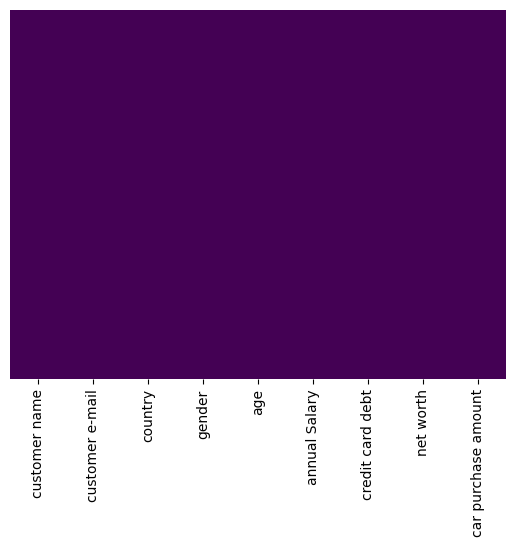

In [8]:
#visualize the nan values in heatmap
sns.heatmap(df.isnull(),yticklabels=False, cbar=False, cmap='viridis')

In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"    Removed {duplicates} duplicate rows")

Duplicate Records: 0


In [10]:
# droping columns
df.drop(columns=['customer name', 'customer e-mail', 'country'], inplace=True)

In [11]:
# unique values of all columns in dataset
df.nunique()

gender                   2
age                    500
annual Salary          500
credit card debt       500
net worth              500
car purchase amount    500
dtype: int64

In [12]:
# Checking datatypes of columns
df.dtypes

gender                   int64
age                    float64
annual Salary          float64
credit card debt       float64
net worth              float64
car purchase amount    float64
dtype: object

In [13]:
# Statistics of dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,500.0,0.506000,0.500465,0.0,0.000000,1.000000,1.000000,1.0
age,500.0,46.241674,7.978862,20.0,40.949969,46.049901,51.612263,70.0
annual Salary,500.0,62127.239608,11703.378228,20000.0,54391.977195,62915.497035,70117.862005,100000.0
credit card debt,500.0,9607.645049,3489.187973,100.0,7397.515792,9655.035568,11798.867487,20000.0
net worth,500.0,431475.713625,173536.756340,20000.0,299824.195900,426750.120650,557324.478725,1000000.0
car purchase amount,500.0,44209.799218,10773.178744,9000.0,37629.896040,43997.783390,51254.709517,80000.0


In [14]:
# Outlier Detection using IQR method
print("Outlier Detection (IQR Method):")
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary[col] = outliers
    print(f"   {col}: {outliers} outliers")
    print("-" * 80)

Outlier Detection (IQR Method):
   gender: 0 outliers
--------------------------------------------------------------------------------
   age: 4 outliers
--------------------------------------------------------------------------------
   annual Salary: 2 outliers
--------------------------------------------------------------------------------
   credit card debt: 7 outliers
--------------------------------------------------------------------------------
   net worth: 1 outliers
--------------------------------------------------------------------------------
   car purchase amount: 5 outliers
--------------------------------------------------------------------------------


<Axes: >

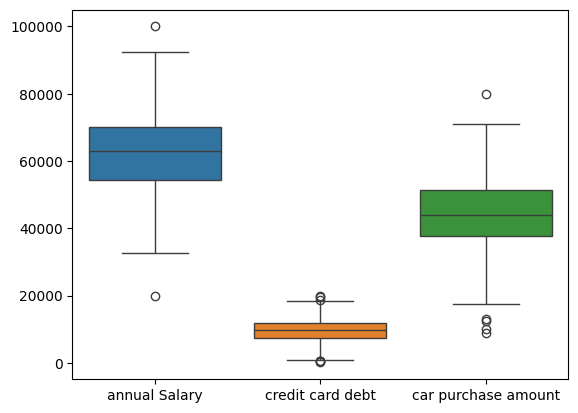

In [15]:
#  Boxplot for Checking Outliers
sns.boxplot(df[['annual Salary', 'credit card debt', 'car purchase amount']])

##  Feature Engineering:

In [16]:
# Debt to income ratio
df['debt_to_income_ratio'] = df['credit card debt'] / df['annual Salary']
df['debt_to_income_ratio']

0      0.184827
1      0.143637
2      0.207447
3      0.181758
4      0.089717
         ...   
495    0.097243
496    0.219514
497    0.154040
498    0.281319
499    0.153027
Name: debt_to_income_ratio, Length: 500, dtype: float64

In [17]:
# Net worth to salary ratio
df['networth_to_salary_ratio'] = df['net worth'] / df['annual Salary']
df['networth_to_salary_ratio']

0       3.804383
1       7.966972
2      11.867739
3       6.911916
4       9.380747
         ...    
495     7.529219
496     6.431519
497    11.098053
498     6.782034
499     7.543448
Name: networth_to_salary_ratio, Length: 500, dtype: float64

In [18]:
# Purchase power (combination of salary and net worth)
df['purchase_power'] = df['annual Salary'] * 0.3 + df['net worth'] * 0.7
df['purchase_power']

0      186116.503253
1      391675.803336
2      463066.589446
3      407830.348074
4      410131.592360
           ...      
495    400751.791993
496    269105.218539
497    555838.557625
498    251422.243926
499    342473.747978
Name: purchase_power, Length: 500, dtype: float64

Text(0, 0.5, 'Frequency')

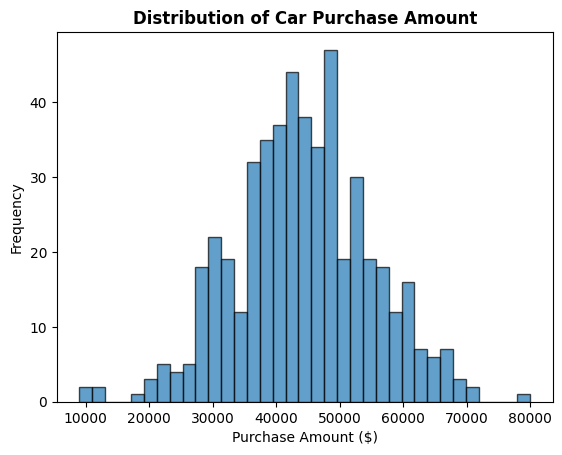

In [19]:
# Target variable distribution
plt.hist(df['car purchase amount'], bins=35, edgecolor='black', alpha=0.7)
plt.title('Distribution of Car Purchase Amount', fontweight='bold')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Frequency')

Text(0.5, 1.0, 'Gender Distribution')

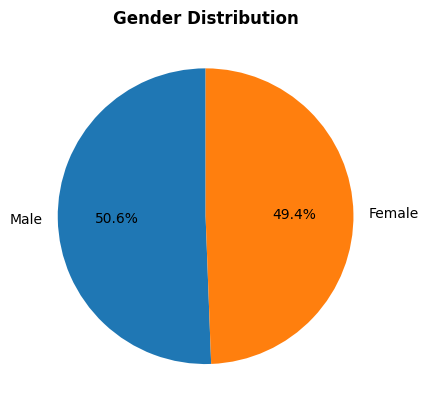

In [20]:
# Gender distribution
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts, labels=['Male' if x==1 else 'Female' for x in gender_counts.index], 
        autopct='%.1f%%', startangle=90)
plt.title('Gender Distribution', fontweight='bold')

Text(0, 0.5, 'Purchase Amount ($)')

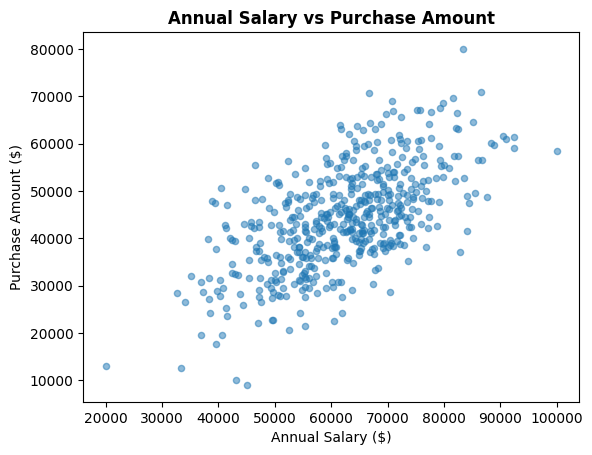

In [21]:
# Salary vs Purchase Amount
plt.scatter(df['annual Salary'], df['car purchase amount'], alpha=0.5, s=20)
plt.title('Annual Salary vs Purchase Amount', fontweight='bold')
plt.xlabel('Annual Salary ($)')
plt.ylabel('Purchase Amount ($)')

Text(0, 0.5, 'Purchase Amount ($)')

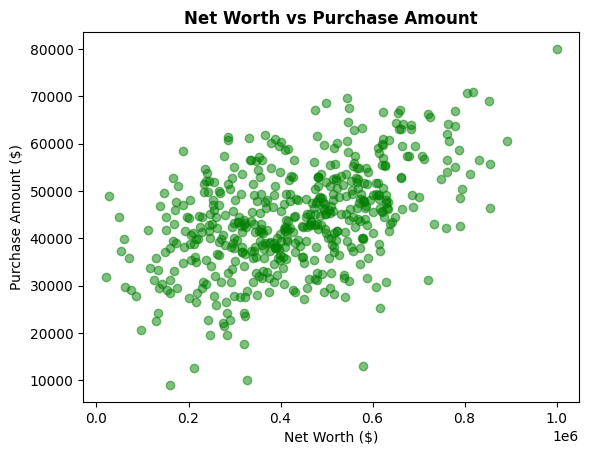

In [22]:
# Net Worth vs Purchase Amount
plt.scatter(df['net worth'], df['car purchase amount'], alpha=0.5,  color='green')
plt.title('Net Worth vs Purchase Amount', fontweight='bold')
plt.xlabel('Net Worth ($)')
plt.ylabel('Purchase Amount ($)')

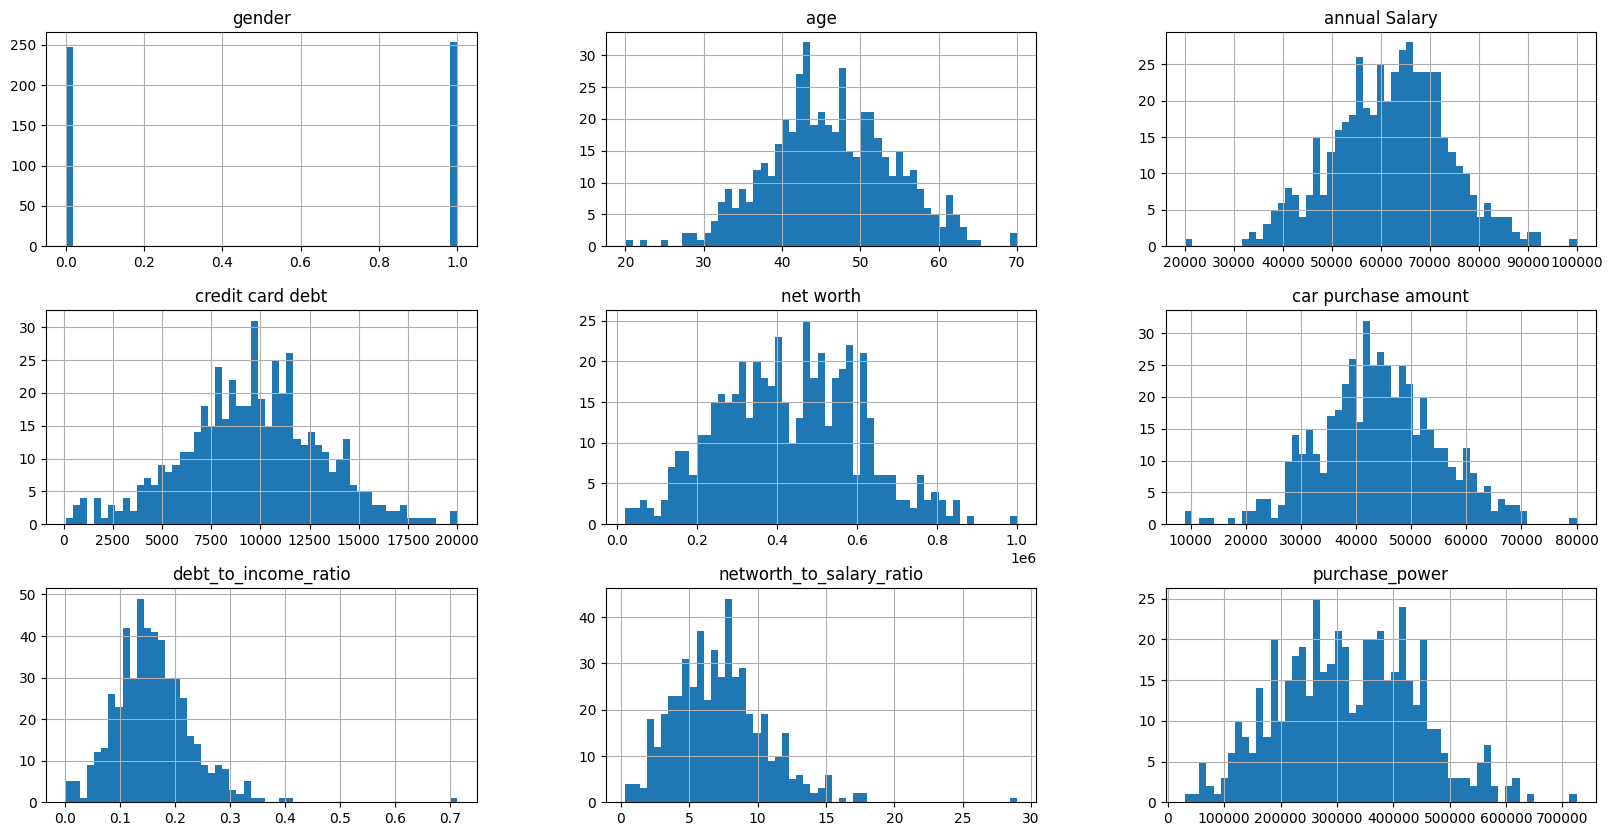

In [23]:
# Create a histogram for the DataFrame
df.hist(bins=55, figsize=(20,10))
plt.show()

Index(['gender', 'age', 'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount', 'debt_to_income_ratio',
       'networth_to_salary_ratio', 'purchase_power'],
      dtype='object')


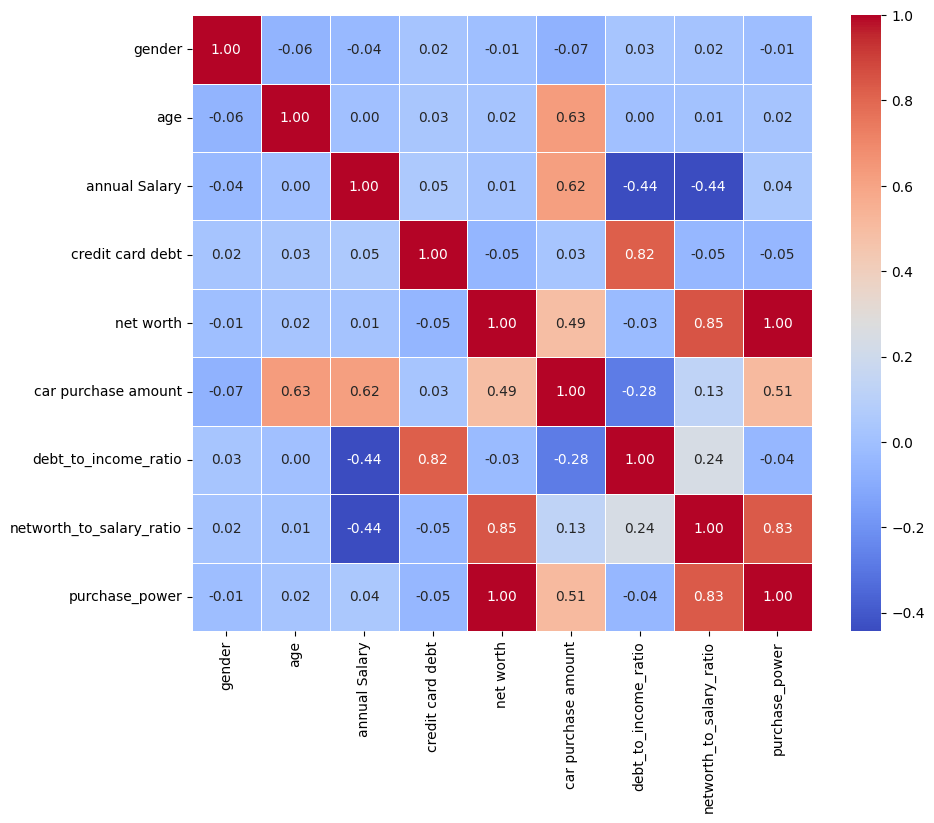

In [24]:
# Plotting the Correlation Matrix
numerical_columns = df.columns
print(numerical_columns)
correlation_matrix = df[numerical_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.show()

- High Correlation between `car purchase amount` and `annual Salary`\.

### Define and Split data

In [25]:
# Defining X and y
X = df.drop(columns=['car purchase amount'])
y = df['car purchase amount']

# Shapes of X and y
print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (500, 8)
Shape of y:  (500,)


In [26]:
# Scaling the data 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
y_scaled = scaler.fit_transform(y.to_frame())

# Shapes
print("Shape of X_scaled: ", X_scaled.shape)
print("Shape of y_scaled: ", y_scaled.shape)

Shape of X_scaled:  (500, 8)
Shape of y_scaled:  (500, 1)


## Splitting Data

In [36]:
from sklearn.model_selection import train_test_split
# Spliting data for training and testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, 
                                                    y_scaled, test_size=0.2, random_state=42)

In [28]:
# Shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (400, 8)
y_train shape: (400, 1)
X_test shape: (100, 8)
y_test shape: (100, 1)


## **Model Development**

In [29]:
#  Import library & Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Fitting the model
model.fit(X_train, y_train)

# Predicting X_test
y_pred= model.predict(X_test)

### Model Evaluation

In [30]:
# Import metrics
from sklearn.metrics import (r2_score, mean_squared_error,
                              mean_absolute_error)

r2 = r2_score(y_test, y_pred)
print("R2_Score: ",r2 )

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error: ",mae )

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ",mse )

R2_Score:  0.9999999805410614
Mean Absolute Error:  1.626056062477399e-05
Mean Squared Error:  4.167909310255074e-10


#### What is R² Score?
**Definition:** Tells you what percentage of variance in the target variable is explained by your model.

**Range:** -∞ to 1.0 (usually 0 to 1)

**Formula:**
```
R² = 1 - (SS_residual / SS_total)

#### What is MAE?

**Definition:** Average of the absolute differences between actual and predicted values.

**Range:** 0 to ∞ (lower is better)

**Formula:**
```
MAE = (1/n) × Σ|actual - predicted|

Where:
n = number of predictions
| | = absolute value (always positive)

#### What is MSE?

**Definition:** Average of the squared differences between actual and predicted values.

**Range:** 0 to ∞ (lower is better)

**Formula:**
```
MSE = (1/n) × Σ(actual - predicted)²

Where:
n = number of predictions
² = squared (always positive, penalizes large errors more)

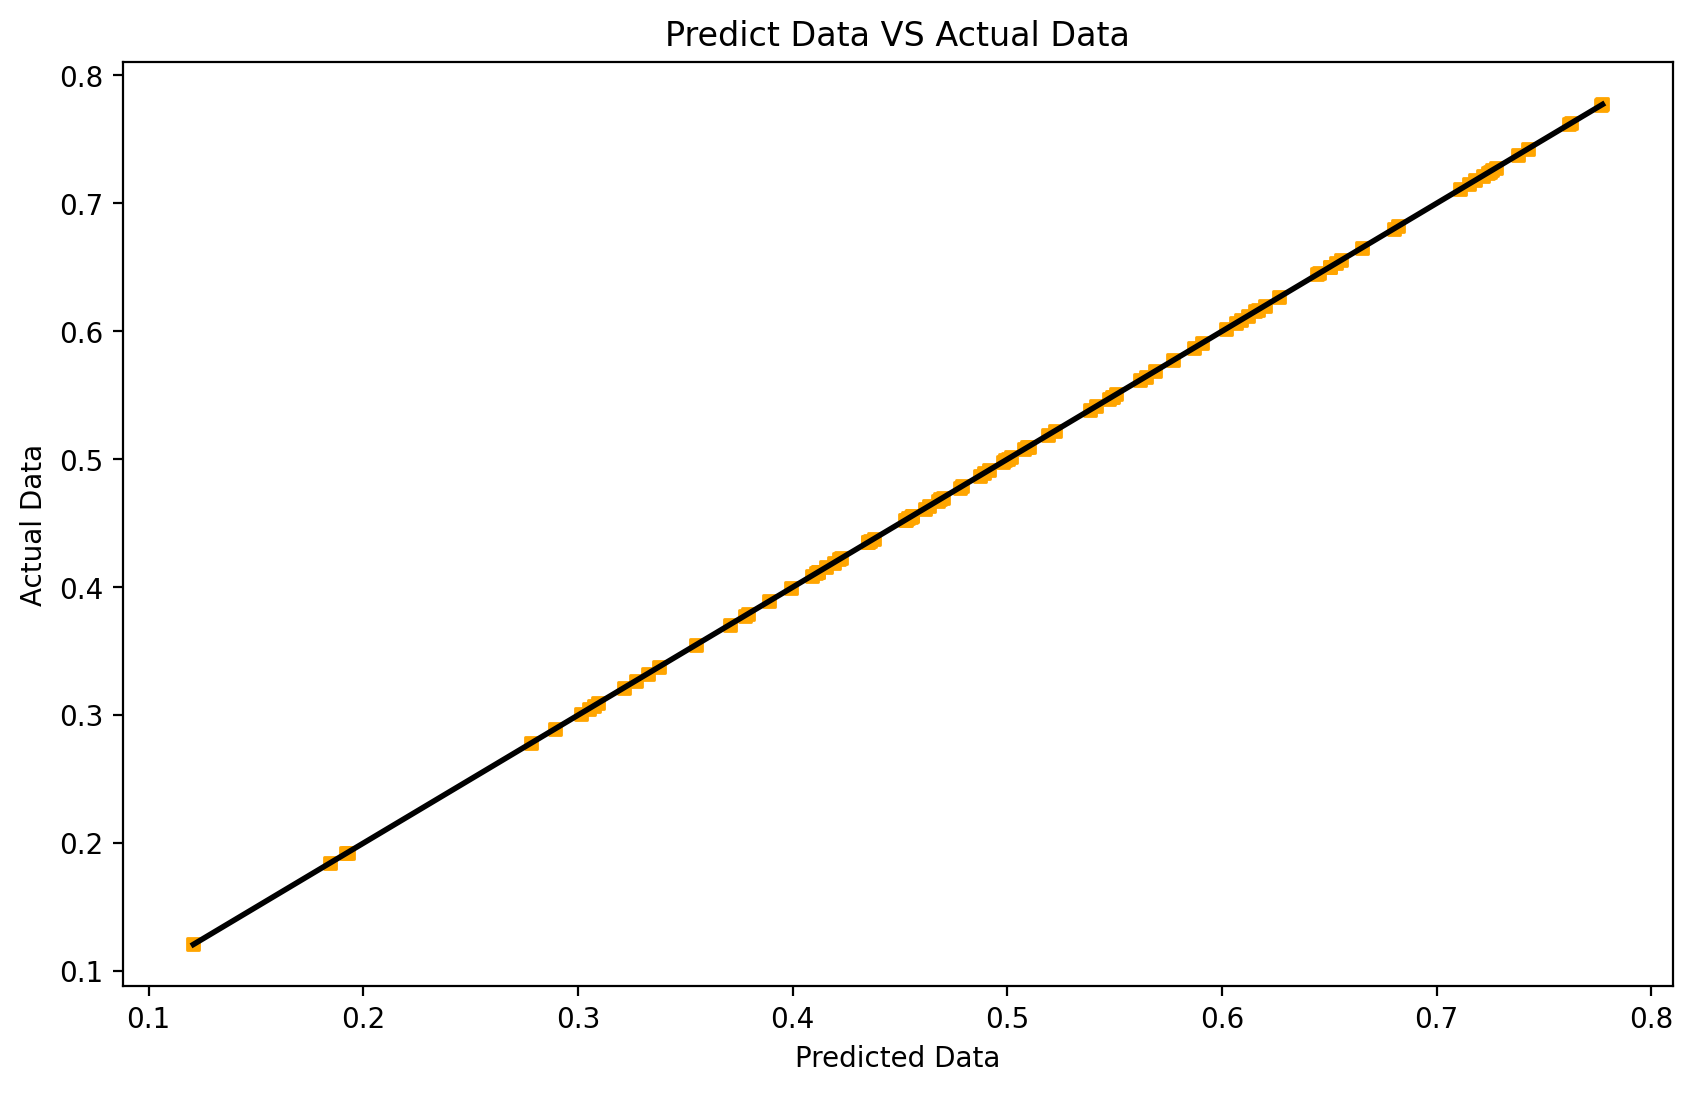

In [31]:
# Create a scatter plot comparing predicted data ('y_pred') to actual data ('y_test')
plt.figure(figsize=(10,6), dpi=200)
plt.scatter(y_pred,y_test,c='orange',marker='s',s=20)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],c='black',lw=2)
plt.xlabel('Predicted Data')
plt.ylabel('Actual Data')
plt.title('Predict Data VS Actual Data')
plt.show()

In [32]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fitting the model
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
# Predicting X_test
y_pred= model.predict(X_test)

In [34]:
# Import metrics
from sklearn.metrics import (r2_score, mean_squared_error,
                              mean_absolute_error)

r2 = r2_score(y_test, y_pred)
print("R2_Score: ",r2 )

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error: ",mae )

mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error: ",mse )

R2_Score:  0.9486197252673243
Mean Absolute Error:  0.023017065690985935
Mean Squared Error:  0.0011005139058944205


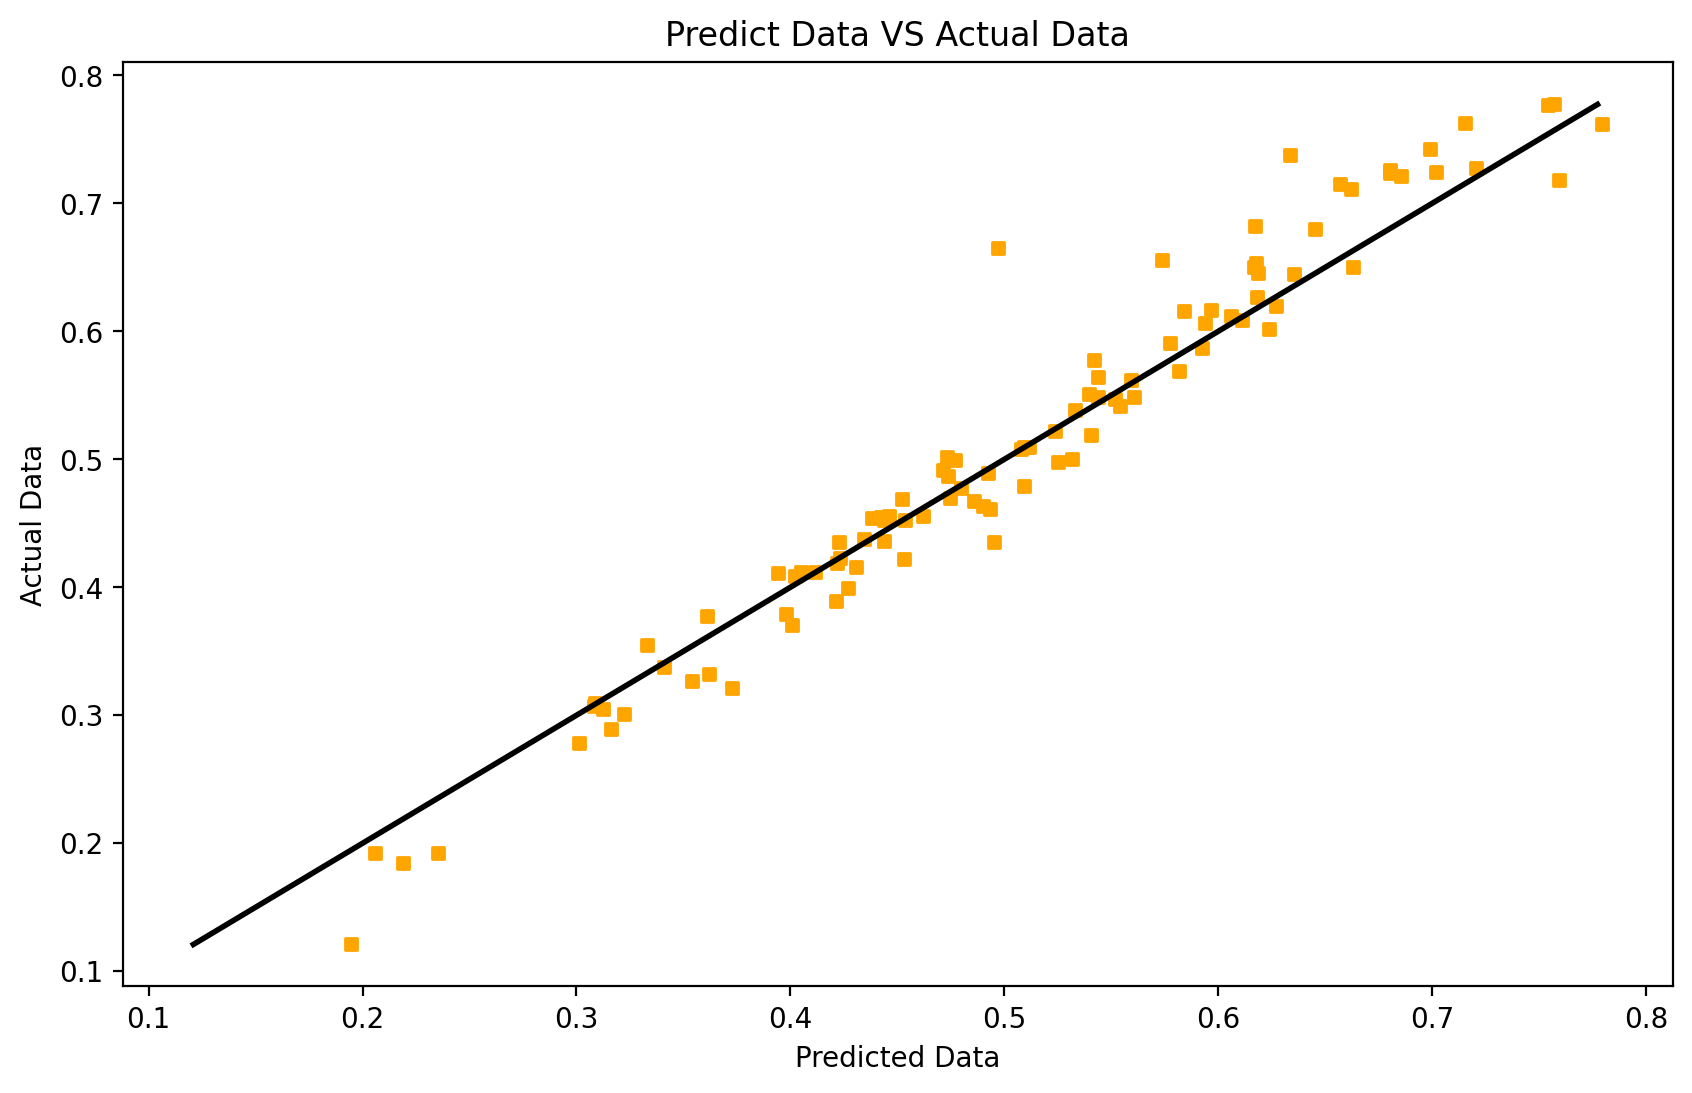

In [35]:
# Create a scatter plot comparing predicted data ('y_pred') to actual data ('y_test')
plt.figure(figsize=(10,6), dpi=200)
plt.scatter(y_pred,y_test,c='orange',marker='s',s=20)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],c='black',lw=2)
plt.xlabel('Predicted Data')
plt.ylabel('Actual Data')
plt.title('Predict Data VS Actual Data')
plt.show()

---
## December 15, 2025